# Attenuator Calibration Lab Script

Dirty science-lab notebook for attenuator calibration. It has two paths:

- embedded auto-calibration: run firmware, retrieve retained HAC4 records, and inspect them with helper plots;
- manual exploration: call `pcb.atten()`, wait, and read `pcb.pd()` so thresholds and failure modes can be changed quickly.

Measure dark in the preceding cell or in the dark cell below before collecting either dataset.


In [3]:
from __future__ import annotations

from dataclasses import asdict, dataclass
import math
import time
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import least_squares

import hispec_fibpcb as hspcb

BROKER = "hispec.caltech.edu"
LASER = "1028y"
OUTPUT = "yj_ao"
FIBER = "M"
PD_CHANNEL = "yj"

TAKE_DARK = False

MANUAL_FIT_METHOD: Literal["firmware", "scipy"] = "firmware"
MANUAL_DWELL_S = .55
MANUAL_DWELL_MS = int(round(MANUAL_DWELL_S * 1000))
MANUAL_SWEEP_STEP_MV = 50.0
MANUAL_COMPANION_SEARCH_MIN_STEP_MV = 5.0
MANUAL_MAX_BRIDGES = 4
MANUAL_MAX_RECORDS = 160
MANUAL_SNR_USABLE = hspcb.ATTENUATOR_CAL_SNR_USABLE
MANUAL_BRIDGE_BACKOFF_SIGNAL_FRACTION = 0.80
MANUAL_DAC_SIGMA_MV = 3.0
MIN_ADC_ERROR_MV = 1.0
TX_MIN = 1.0e-10
TX_MAX = 0.999999
MAX_DAC_MV = hspcb.ATTENUATOR_DRIVE_MAX_MV
ADC_CLIP_MV = hspcb.ATTENUATOR_ADC_CLIP_MV
GAIN = hspcb.ATTENUATOR_DEFAULT_GAIN

pcb = hspcb.HispecFibPcb(BROKER, connect=True)
pcb.status(),pcb.time()

(Status(
   fw='123e025a24b3-dirty',
   boots=9,
   board='tib',
   board_ok=True,
   mems_switches=8,
   relay_err=0,
   amb_c=20.25,
   pd_on_s=0,
   laserbank_on_s=52492,
   lastcmd=LastCommand(name='atten/calibrate', src='mqtt', t_ms=1802359),
   ip=None,
   lasers=(),
   attens=()
 ),
 TimeStatus(utc=1781886380382, uptime_s=52493))

PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=121.419 threshold_mv=10.000 uptime_s=0
PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=121.419 threshold_mv=10.000 uptime_s=0
PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=121.419 threshold_mv=10.000 uptime_s=0


## Dark

Keep `persist=False` while exploring. Switch to `True` only after reviewing the dark value and noise. Duration captures return immediately, so wait before querying the resulting dark.


In [4]:
pcb.pd(PD_CHANNEL)

PhotodiodeValues(
  yj=PhotodiodeChannelValues(
  raw=21451,
  mv=4022.06,
  net_mv=4023.5,
  net_err_mv=1.21,
  power_uw=8.7e-05,
  power_err_uw=0,
  dark_mv=-1.434,
  dark_err_mv=1.195,
  window=PhotodiodeWindow(
  duration_ms=500,
  failed_samples=0,
  mean_mv=4192.36,
  mean_net_mv=4193.79,
  rms_mv=244.082,
  mean_net_err_mv=48.831,
  min_mv=3690,
  max_mv=4520.62,
  power_uw=9e-05,
  power_err_uw=1e-06
),
  pd_is_off=False,
  ontime_s=0
),
  hk=None
)

In [5]:
pcb.pd_dark(PD_CHANNEL)

PhotodiodeDark(
  channel='yj',
  pending=False,
  duration_ms=0,
  dark=PhotodiodeWindow(
  duration_ms=2000,
  failed_samples=0,
  mean_mv=-1.434,
  mean_net_mv=0,
  rms_mv=1.195,
  mean_net_err_mv=1.195,
  min_mv=-4.5,
  max_mv=1.688,
  power_uw=0,
  power_err_uw=0
),
  lowest_dark=PhotodiodeWindow(
  duration_ms=2000,
  failed_samples=0,
  mean_mv=-1.622,
  mean_net_mv=0,
  rms_mv=1.296,
  mean_net_err_mv=1.296,
  min_mv=-4.312,
  max_mv=1.312,
  power_uw=0,
  power_err_uw=0
)
)

In [6]:
if TAKE_DARK:
    pcb.set_laser_level(LASER, 0)
    dark_duration_ms = 2000
    pcb.pd_dark(PD_CHANNEL, duration_ms=dark_duration_ms, persist=True)
    time.sleep(dark_duration_ms / 1000 + 0.25)
    dark = pcb.pd_dark(PD_CHANNEL)
    dark.dark


## Embedded Firmware Path

This is the authoritative firmware algorithm. It stores retained records in firmware and returns them through `atten_calibration_data()` after or during the run.


In [5]:
embedded_status = pcb.atten_calibrate_auto(
    LASER,
    output=OUTPUT,
    fiber=FIBER,
    dwell_ms=MANUAL_DWELL_MS,
    persist=False,
)
embedded_status


PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=10.475 threshold_mv=10.000 uptime_s=0


AttenuatorCalibrationStatus(
  state='running', mode='tib_auto', physical='dac1', point='1/128', complete_pct=0,
  mv=0, other_mv=3300, t_ms=550, error=0, fit='none',
  dac1=AttenuatorFitMetrics(valid=False),
  dac2=AttenuatorFitMetrics(valid=False)
)

In [9]:
pcb.atten_calibration_status()


AttenuatorCalibrationStatus(
  state='error', mode='tib_auto', physical='dac1', point='11/128', complete_pct=4,
  mv=0, other_mv=2723.14, t_ms=550, error=-34, fit='failed',
  dac1=AttenuatorFitMetrics(valid=False),
  dac2=AttenuatorFitMetrics(valid=False)
)

In [10]:
embedded = pcb.atten_calibration_data(physical="all")
embedded


AttenuatorCalibrationDataset(records=11, physicals=('dac1',), counts=(('dac1', 11),))

In [11]:
embedded.bridge_table()


,physical,bridge_index,boundary_index,before_record,after_record,from_segment,to_segment,sweep_mv,other_before_mv,other_after_mv,signal_before_mv,signal_after_mv,ratio,ratio_rel_var


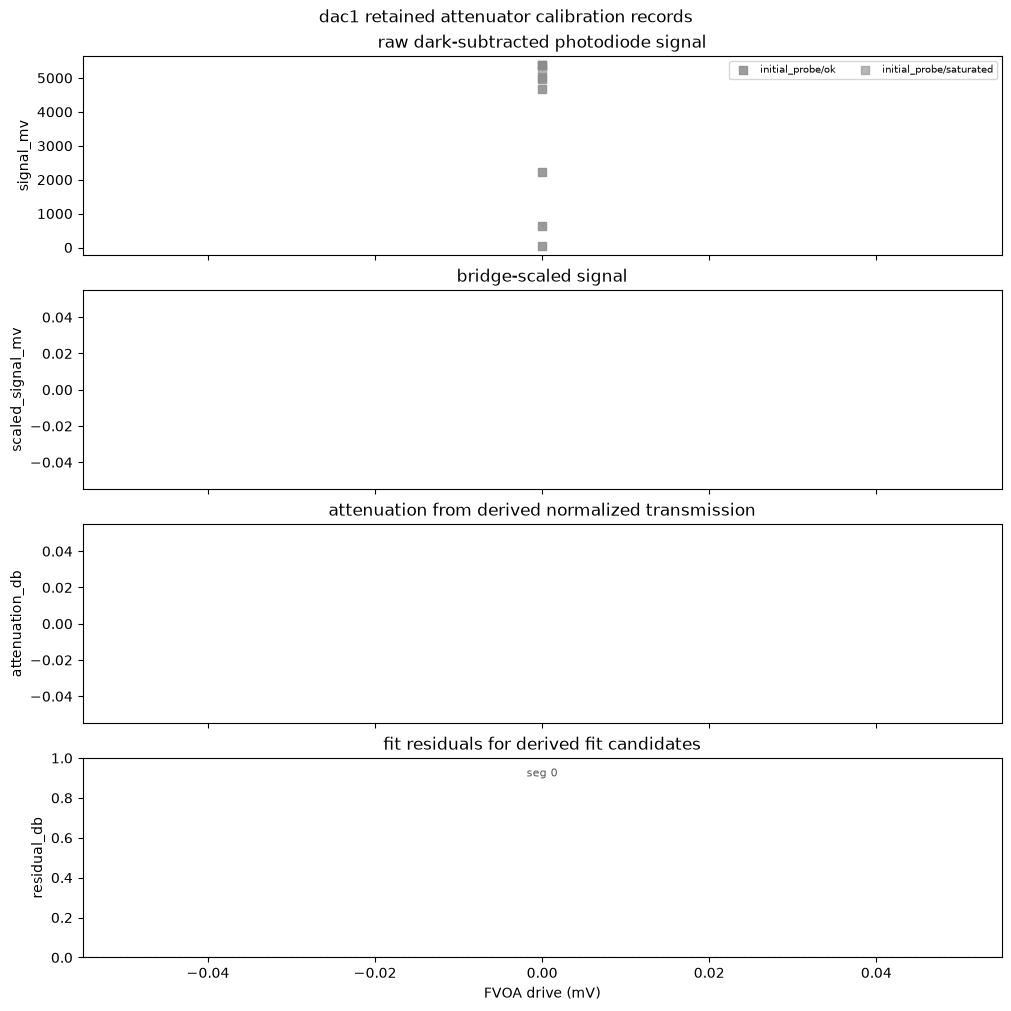

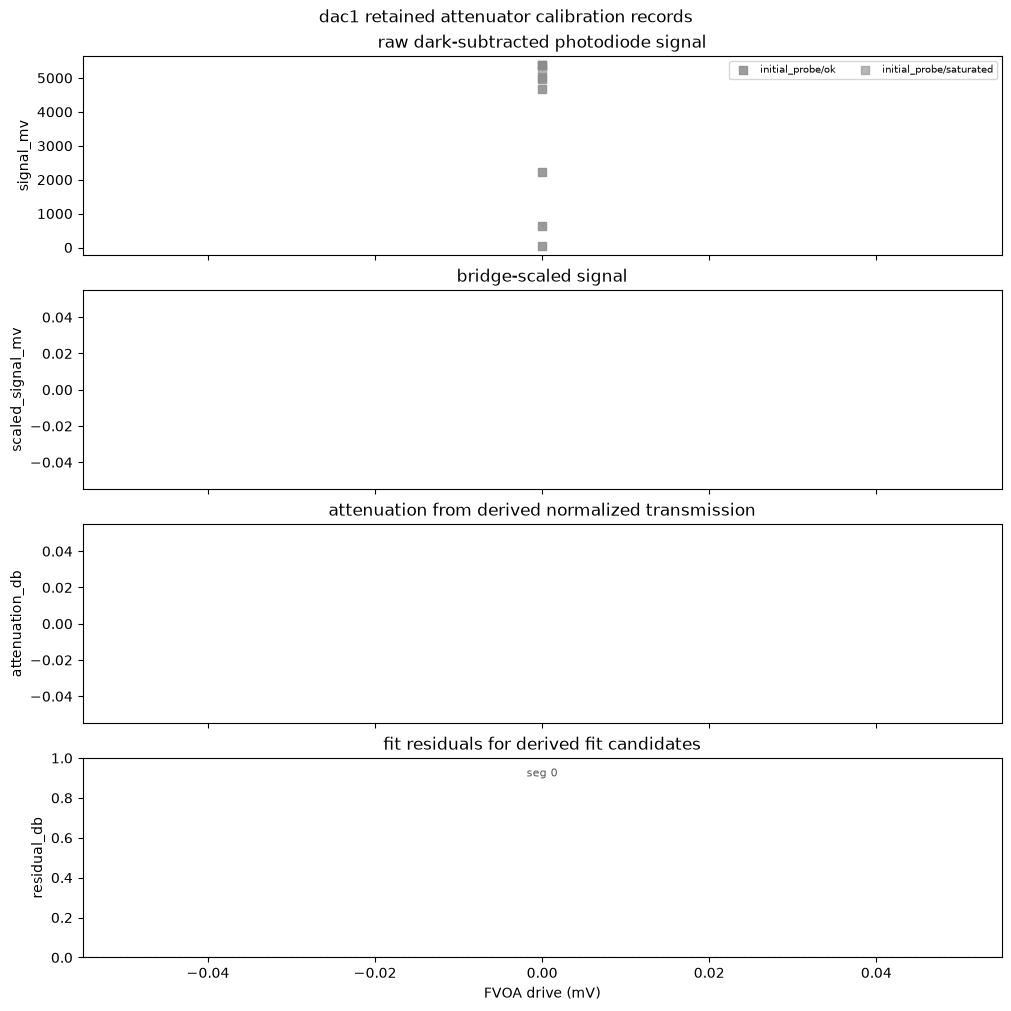

In [13]:
embedded.plot_physical("dac1")
# embedded.plot_physical("dac2")


/Users/jibailey/src/hispec-zephyr-mlang/hispec-tib/tools/hispec_fibpcb.py:2762: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best", fontsize="x-small", ncol=2)


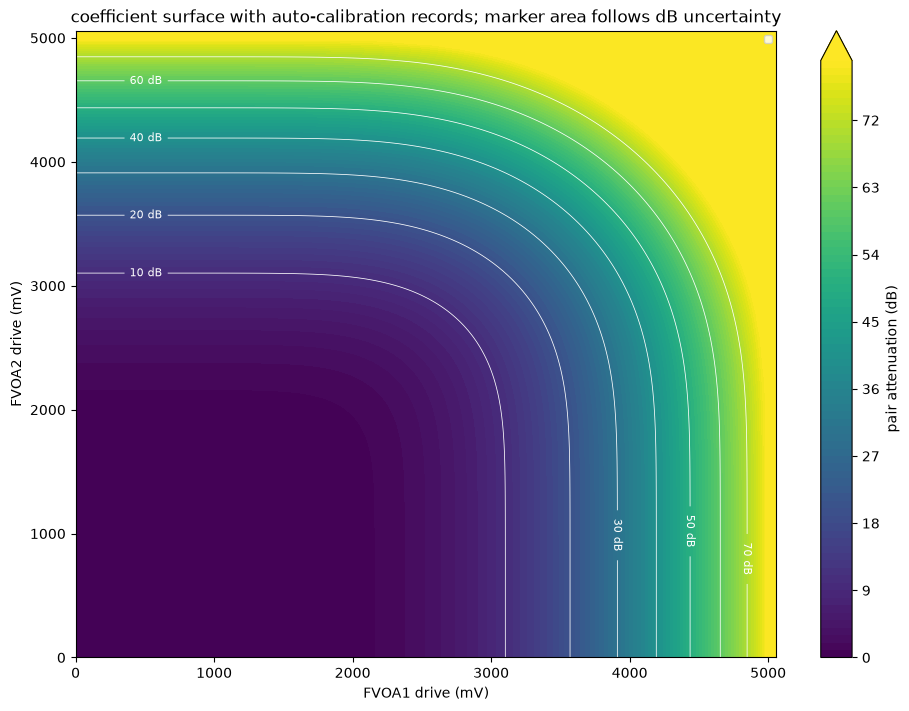

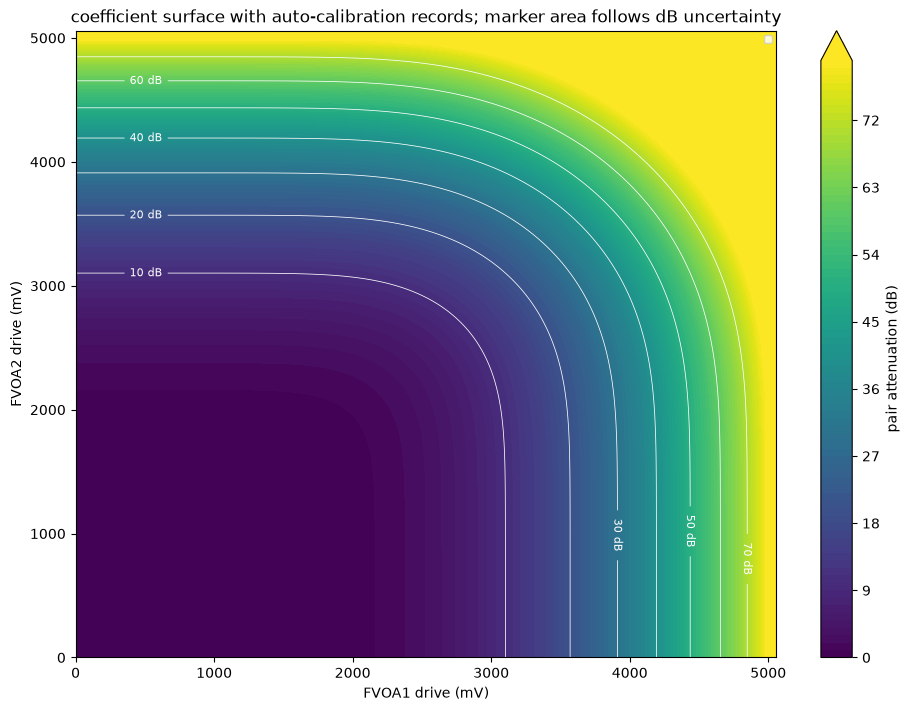

PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=153.416 threshold_mv=10.000 uptime_s=0


In [14]:
coeff = pcb.atten_coeff(LASER)
embedded.plot_surface(coeff.dac1, coeff.dac2, axis="fvoa_mv", overlay_records=True)


## Manual Exploration Path

This section intentionally reimplements acquisition with direct `pcb.atten()`, `sleep`, and `pcb.pd()` calls. It is a lab script, not production code. The point is to make thresholds, bridge behavior, and failure modes easy to probe while still using the same raw-record framing as firmware.

Raw records contain only measured acquisition facts: event, classification, segment, swept DAC, companion DAC, laser percent, net photodiode signal, signal uncertainty, and window max. Bridge ratios, scaled signal, tx, dB, dB uncertainty, fit inclusion, and residuals are derived afterward from the raw records and accepted bridge boundaries.

The manual fit toggle is required:

```python
MANUAL_FIT_METHOD = "firmware"  # finite-difference dB-space optimizer matching firmware
MANUAL_FIT_METHOD = "scipy"     # SciPy least_squares using the same dB residuals
```

The swept FVOA is sampled linearly from 0 mV to maximum drive in `MANUAL_SWEEP_STEP_MV` increments; only companion start and bridge recovery use binary search. A saturated sweep sample is a bright-side diagnostic and advances the sweep toward more attenuation. A below-SNR sample starts bridge normalization from the latest usable swept anchor. Bridge probing searches for the brightest non-saturated companion setting; accepted `bridge_after` records define segment scale and are not fit candidates.


In [8]:
@dataclass
class CalRecord:
    physical: str
    event: str
    classification: str
    segment: int
    sweep_mv: float
    other_mv: float
    laser_pct: float
    signal_mv: float
    signal_err_mv: float
    max_mv: float

    @property
    def usable(self) -> bool:
        return self.classification == "ok" and self.signal_mv > 0.0 and self.signal_err_mv > 0.0

    @property
    def acq_snr(self) -> float:
        return self.signal_mv / self.signal_err_mv if self.signal_err_mv > 0.0 else np.nan


def _set_pair(physical: str, sweep_mv: float, other_mv: float):
    sweep_mv = float(np.clip(sweep_mv, 0.0, MAX_DAC_MV))
    other_mv = float(np.clip(other_mv, 0.0, MAX_DAC_MV))
    if physical == "dac1":
        return pcb.atten(LASER, value1_mv=sweep_mv, value2_mv=other_mv)
    if physical == "dac2":
        return pcb.atten(LASER, value1_mv=other_mv, value2_mv=sweep_mv)
    raise ValueError("physical must be dac1 or dac2")


def _pd_window(channel: str = PD_CHANNEL):
    pd = pcb.pd(channel)
    return getattr(pd, channel).window


def _classify_window(window) -> tuple[str, float, float, float, float]:
    signal_mv = float(window.mean_net_mv)
    signal_err_mv = max(float(window.mean_net_err_mv), MIN_ADC_ERROR_MV)
    max_mv = float(window.max_mv)
    snr = signal_mv / signal_err_mv if signal_err_mv > 0.0 else np.nan
    if signal_mv >= ADC_CLIP_MV:
        classification = "saturated"
    elif signal_mv > 0.0 and np.isfinite(snr) and snr >= MANUAL_SNR_USABLE:
        classification = "ok"
    else:
        classification = "below_snr"
    return classification, signal_mv, signal_err_mv, max_mv, snr


def measure_point(physical: str, sweep_mv: float, other_mv: float,
                  *,
                  event: str = "point",
                  segment: int = 0,
                  laser_pct: float = 100.0,
                 ) -> CalRecord:
    
    _set_pair(physical, sweep_mv, other_mv)
    
    time.sleep(MANUAL_DWELL_S)

    pd_win = _pd_window(PD_CHANNEL)
    classification, signal_mv, signal_err_mv, max_mv, snr = _classify_window(pd_win)
    
    rec = CalRecord(
        physical=physical,
        event=event,
        classification=classification,
        segment=int(segment),
        sweep_mv=float(sweep_mv),
        other_mv=float(other_mv),
        laser_pct=float(laser_pct),
        signal_mv=signal_mv,
        signal_err_mv=signal_err_mv,
        max_mv=max_mv,
    )
    print(
        f"{event:14s} {physical}={sweep_mv:6.2f} other={other_mv:6.2f} "
        f"signal={signal_mv:.0f}±{signal_err_mv:6.3f} snr={snr:8.0f} "
        f"class={classification:10s} segment={segment}"
    )
    return rec


def records_to_dataset(records: list[CalRecord]) -> hspcb.AttenuatorCalibrationDataset:
    rows = []
    for i, rec in enumerate(records):
        rows.append((
            rec.physical,
            i,
            rec.event,
            rec.classification,
            rec.segment,
            rec.sweep_mv,
            rec.sweep_mv * GAIN,
            rec.other_mv,
            rec.other_mv * GAIN,
            rec.laser_pct,
            rec.signal_mv,
            rec.signal_err_mv,
            rec.max_mv,
        ))
    return hspcb.AttenuatorCalibrationDataset(
        np.array(rows, dtype=hspcb.ATTEN_CAL_DTYPE).view(np.recarray)
    )


PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=285.167 threshold_mv=10.000 uptime_s=0
PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=285.167 threshold_mv=10.000 uptime_s=0
PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=285.167 threshold_mv=10.000 uptime_s=0
PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=191.068 threshold_mv=10.000 uptime_s=0
PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=191.068 threshold_mv=10.000 uptime_s=0
PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=191.068 threshold_mv=10.000 uptime_s=0


In [9]:
def _update_companion_bracket(
    rec: CalRecord,
    low_mv: float,
    high_mv: float,
    candidate_mv: float | None,
    *,
    min_step_mv: float = MANUAL_COMPANION_SEARCH_MIN_STEP_MV,
) -> tuple[float, float, float | None]:
    if rec.classification == "saturated":
        low_mv = rec.other_mv
        if candidate_mv is not None and abs(candidate_mv - rec.other_mv) <= min_step_mv:
            candidate_mv = None
    elif rec.classification == "ok":
        high_mv = rec.other_mv
        candidate_mv = rec.other_mv
    elif rec.classification == "below_snr":
        high_mv = rec.other_mv
        if candidate_mv is not None and abs(candidate_mv - rec.other_mv) <= min_step_mv:
            candidate_mv = None
    else:
        raise RuntimeError(f"companion search failed at {rec.other_mv:.2f} mV: {rec.classification}")
    return low_mv, high_mv, candidate_mv


def find_lowest_usable_companion(
    physical: str,
    sweep_mv: float,
    *,
    segment: int,
    low_mv: float = 0.0,
    high_mv: float = MAX_DAC_MV,
    candidate_mv: float | None = None,
    event: str = "initial_probe",
    min_step_mv: float = MANUAL_COMPANION_SEARCH_MIN_STEP_MV,
    max_probes: int = 16,
    laser_pct: float = 100.0,
) -> tuple[float | None, list[CalRecord], float, float]:
    """ Find a voltage to drive the companion such that there is near maximal unsaturated signal on the PD 
    find this by tuning only the companion dac leaving the sweep_mv fixed. """
    records: list[CalRecord] = []
    for _ in range(max_probes):
        if high_mv - low_mv <= min_step_mv:
            break
        mid = 0.5 * (low_mv + high_mv)
        rec = measure_point(physical, sweep_mv, mid, event=event, segment=segment, laser_pct=laser_pct)
        records.append(rec)
        low_mv, high_mv, candidate_mv = _update_companion_bracket(
            rec,
            low_mv,
            high_mv,
            candidate_mv,
            min_step_mv=min_step_mv,
        )
    return candidate_mv, records, low_mv, high_mv


def _reference_retry_candidate(
    records: list[CalRecord],
    classification: str,
    failed_other_mv: float,
    segment: int,
    *,
    min_step_mv: float = MANUAL_COMPANION_SEARCH_MIN_STEP_MV,
) -> float | None:
    candidates = [
        rec.other_mv
        for rec in records
        if rec.event == "initial_probe"
        and rec.segment == segment
        and rec.classification == "ok"
    ]
    if classification == "saturated":
        safer = [mv for mv in candidates if mv > failed_other_mv + min_step_mv]
        return min(safer) if safer else None
    if classification == "below_snr":
        brighter = [mv for mv in candidates if mv < failed_other_mv - min_step_mv]
        return max(brighter) if brighter else None
    return None


def _measure_confirmed_reference(
    physical: str,
    records: list[CalRecord],
    companion_mv: float,
    segment: int,
    *,
    laser_pct: float,
    min_step_mv: float = MANUAL_COMPANION_SEARCH_MIN_STEP_MV,
) -> float:
    tried: set[float] = set()
    while True:
        reference = measure_point(
            physical,
            0.0,
            companion_mv,
            event="reference",
            segment=segment,
            laser_pct=laser_pct,
        )
        records.append(reference)
        if reference.usable:
            return companion_mv
        if reference.classification not in ("saturated", "below_snr"):
            raise RuntimeError(f"{physical} reference is not usable: {reference.classification}")
        tried.add(round(companion_mv, 6))
        retry_mv = _reference_retry_candidate(
            records,
            reference.classification,
            companion_mv,
            segment,
            min_step_mv=min_step_mv,
        )
        if retry_mv is None or round(retry_mv, 6) in tried:
            raise RuntimeError(f"{physical} reference is not usable: {reference.classification}")
        print(
            f"reference retry {physical}: from={companion_mv:.2f} to={retry_mv:.2f} "
            f"classification={reference.classification}"
        )
        companion_mv = retry_mv


def _latest_anchor(records: list[CalRecord], segment: int, other_mv: float) -> CalRecord | None:
    for rec in reversed(records):
        if (
            rec.segment == segment
            and rec.event in ("point", "bridge_after", "reference")
            and rec.classification == "ok"
            and abs(rec.other_mv - other_mv) <= MANUAL_COMPANION_SEARCH_MIN_STEP_MV
        ):
            return rec
    return None


def _truncate_to_record(records: list[CalRecord], keep: CalRecord) -> None:
    idx = records.index(keep)
    del records[idx + 1:]


def _confirm_bridge(
    physical: str,
    anchor: CalRecord,
    other_mv: float,
    segment: int,
    *,
    laser_pct: float,
    min_step_mv: float = MANUAL_COMPANION_SEARCH_MIN_STEP_MV,
) -> tuple[float, list[CalRecord]] | None:
    bridge_records: list[CalRecord] = []
    before = measure_point(
        physical,
        anchor.sweep_mv,
        other_mv,
        event="bridge_before",
        segment=segment,
        laser_pct=laser_pct,
    )
    bridge_records.append(before)
    if not before.usable:
        return None

    low_mv = 0.0
    high_mv = other_mv
    candidate_mv: float | None = other_mv
    probes_used = 0
    while probes_used < 16:
        candidate_mv, probes, low_mv, high_mv = find_lowest_usable_companion(
            physical,
            anchor.sweep_mv,
            segment=segment,
            low_mv=low_mv,
            high_mv=high_mv,
            candidate_mv=candidate_mv,
            event="bridge_probe",
            min_step_mv=min_step_mv,
            max_probes=16 - probes_used,
            laser_pct=laser_pct,
        )
        bridge_records.extend(probes)
        probes_used += len(probes)
        if candidate_mv is None or candidate_mv >= other_mv - min_step_mv:
            return None
        after = measure_point(
            physical,
            anchor.sweep_mv,
            candidate_mv,
            event="bridge_after",
            segment=segment + 1,
            laser_pct=laser_pct,
        )
        if after.usable and after.signal_mv > before.signal_mv:
            bridge_records.append(after)
            return candidate_mv, bridge_records
        after.event = "bridge_probe"
        after.segment = segment
        bridge_records.append(after)
        if after.usable and after.signal_mv <= before.signal_mv:
            high_mv = after.other_mv
            if candidate_mv is not None and abs(candidate_mv - after.other_mv) <= min_step_mv:
                candidate_mv = None
        else:
            low_mv, high_mv, candidate_mv = _update_companion_bracket(
                after,
                low_mv,
                high_mv,
                candidate_mv,
                min_step_mv=min_step_mv,
            )
    return None


In [10]:
def acquire_physical(
    physical: Literal["dac1", "dac2"],
    *,
    step_mv: float = MANUAL_SWEEP_STEP_MV,
    laser_pct: float = 100.0,
) -> list[CalRecord]:
    records: list[CalRecord] = []
    segment = 0
    sweep_mv = 0.0

    companion_mv, probes, _, _ = find_lowest_usable_companion(
        physical,
        0.0,
        segment=segment,
        event="initial_probe",
        min_step_mv=MANUAL_COMPANION_SEARCH_MIN_STEP_MV,
        laser_pct=laser_pct,
    )
    records.extend(probes)
    if companion_mv is None:
        raise RuntimeError(f"{physical} initial companion search found no usable point")

    other_mv = _measure_confirmed_reference(
        physical,
        records,
        companion_mv,
        segment,
        laser_pct=laser_pct,
        min_step_mv=MANUAL_COMPANION_SEARCH_MIN_STEP_MV,
    )

    while len(records) < MANUAL_MAX_RECORDS:
        rec = measure_point(physical, sweep_mv, other_mv, event="point", segment=segment, laser_pct=laser_pct)
        records.append(rec)

        if rec.classification in ("ok", "saturated"):
            if sweep_mv >= MAX_DAC_MV - 1.0e-9:
                break
            sweep_mv = min(MAX_DAC_MV, sweep_mv + step_mv)
            continue

        if rec.classification != "below_snr":
            raise RuntimeError(f"{physical} sweep failed: {rec.classification}")

        if sweep_mv >= MAX_DAC_MV - 1.0e-9:
            break

        anchor = _latest_anchor(records, segment, other_mv)
        if anchor is None:
            raise RuntimeError(f"{physical} has no bridge anchor in segment {segment}")

        segment_records = [
            r for r in records
            if r.segment == segment
            and r.event in ("point", "bridge_after", "reference")
            and r.usable
            and abs(r.other_mv - other_mv) <= MANUAL_COMPANION_SEARCH_MIN_STEP_MV
        ]
        max_backoffs = max(1, len(segment_records) // 2)
        bridge_result = None
        for attempt in range(max_backoffs):
            candidate_anchor = segment_records[-1 - attempt]
            _truncate_to_record(records, candidate_anchor)
            bridge_result = _confirm_bridge(
                physical,
                candidate_anchor,
                other_mv,
                segment,
                laser_pct=laser_pct,
                min_step_mv=MANUAL_COMPANION_SEARCH_MIN_STEP_MV,
            )
            if bridge_result is not None:
                records.extend(bridge_result[1])
                other_mv = bridge_result[0]
                sweep_mv = min(MAX_DAC_MV, candidate_anchor.sweep_mv + step_mv)
                segment += 1
                break
            print(
                f"bridge backoff {physical}: sweep={candidate_anchor.sweep_mv:.2f} "
                f"attempt={attempt + 1}/{max_backoffs}"
            )
        if bridge_result is None:
            raise RuntimeError(f"{physical} bridge failed after {max_backoffs} backoff attempts")
    return records


In [11]:
def _manual_fit_points(records: list[CalRecord], *, gain: float = GAIN):
    derived = records_to_dataset(records).derived()
    mask = np.asarray(derived.fit_candidate, dtype=bool) & np.isfinite(derived.db) & np.isfinite(derived.db_err)
    points = derived[mask].view(np.recarray)
    if len(points) < 6:
        raise RuntimeError(f"not enough fit records: {len(points)}")
    return points


def _manual_model_db(params, dac_mv, *, gain: float = GAIN):
    return hspcb._atten_db_from_coeff((float(params[0]), float(params[1]), gain), dac_mv)


def _manual_model_d_db_d_dac(params, dac_mv, *, gain: float = GAIN):
    step = max(MANUAL_DAC_SIGMA_MV, 0.5)
    dac = np.asarray(dac_mv, dtype=float)
    lo = np.clip(dac - step, 0.0, MAX_DAC_MV)
    hi = np.clip(dac + step, 0.0, MAX_DAC_MV)
    span = np.maximum(hi - lo, 1.0e-12)
    return (_manual_model_db(params, hi, gain=gain) - _manual_model_db(params, lo, gain=gain)) / span


def _manual_weighted_residual(params, points, *, gain: float = GAIN):
    model = _manual_model_db(params, points.sweep_mv, gain=gain)
    d_db_d_dac = _manual_model_d_db_d_dac(params, points.sweep_mv, gain=gain)
    sigma = np.sqrt(points.db_err * points.db_err + (d_db_d_dac * MANUAL_DAC_SIGMA_MV) ** 2)
    return (model - points.db) / np.maximum(sigma, hspcb.ATTEN_CAL_MIN_DB_ERR)


def _manual_initial_guess(points, *, gain: float = GAIN):
    x = np.asarray(points.sweep_mv, dtype=float) * gain
    db = np.asarray(points.db, dtype=float)
    f50 = float(x[np.nanargmin(np.abs(db - 3.01029995664))])
    span = float(np.nanmax(x) - np.nanmin(x))
    slope = 8.0 / span if span > 0.0 else 8.0 / (MAX_DAC_MV * gain)
    return np.array([np.clip(f50, 1.0, 2.0 * MAX_DAC_MV * gain), np.clip(slope, 1.0e-12, 1.0)])


def fit_records_firmware_style(records: list[CalRecord], *, gain: float = GAIN):
    points = _manual_fit_points(records, gain=gain)
    params = _manual_initial_guess(points, gain=gain)
    cost = float(np.sum(_manual_weighted_residual(params, points, gain=gain) ** 2))
    lam = 1.0e-3
    for _ in range(30):
        r = _manual_weighted_residual(params, points, gain=gain)
        steps = np.array([max(abs(params[0]) * 1.0e-5, 0.1), max(abs(params[1]) * 1.0e-5, 1.0e-8)])
        j = np.column_stack([
            (_manual_weighted_residual(params + [steps[0], 0.0], points, gain=gain) - r) / steps[0],
            (_manual_weighted_residual(params + [0.0, steps[1]], points, gain=gain) - r) / steps[1],
        ])
        h = j.T @ j + lam * np.eye(2)
        g = j.T @ r
        delta = -np.linalg.solve(h, g)
        trial = params + delta
        trial[0] = np.clip(trial[0], 1.0, 2.0 * MAX_DAC_MV * gain)
        trial[1] = np.clip(trial[1], 1.0e-12, 1.0)
        trial_cost = float(np.sum(_manual_weighted_residual(trial, points, gain=gain) ** 2))
        if np.isfinite(trial_cost) and trial_cost < cost:
            params = trial
            cost = trial_cost
            lam = max(lam * 0.3, 1.0e-12)
        else:
            lam = min(lam * 10.0, 1.0e12)
    return _manual_fit_summary("firmware", records, points, params, gain=gain)


def fit_records_scipy(records: list[CalRecord], *, gain: float = GAIN):
    points = _manual_fit_points(records, gain=gain)
    initial = _manual_initial_guess(points, gain=gain)
    result = least_squares(
        lambda p: _manual_weighted_residual(p, points, gain=gain),
        initial,
        bounds=([0.0, 0.0], [np.inf, np.inf]),
        loss="soft_l1",
        max_nfev=5000,
    )
    return _manual_fit_summary("scipy", records, points, result.x, gain=gain, success=bool(result.success))


def _manual_fit_summary(method: str, records: list[CalRecord], points, params, *, gain: float = GAIN, success: bool = True):
    model = _manual_model_db(params, points.sweep_mv, gain=gain)
    residual = model - points.db
    return {
        "method": method,
        "accepted": bool(success and params[0] > 0.0 and params[1] > 0.0),
        "points": int(len(points)),
        "fvoa_50pct_mv": float(params[0]),
        "slope_inv_fvoa_mv": float(params[1]),
        "gain": float(gain),
        "rms_db": float(np.sqrt(np.mean(residual * residual))),
        "max_abs_db": float(np.max(np.abs(residual))),
    }


def fit_records(records: list[CalRecord], *, method: str = MANUAL_FIT_METHOD, gain: float = GAIN):
    if method == "firmware":
        return fit_records_firmware_style(records, gain=gain)
    if method == "scipy":
        return fit_records_scipy(records, gain=gain)
    raise ValueError("method must be 'firmware' or 'scipy'")


In [12]:
def plot_manual_records(records: list[CalRecord], fit: dict[str, float | int | bool]):
    coeff = (float(fit["fvoa_50pct_mv"]), float(fit["slope_inv_fvoa_mv"]), float(fit["gain"]))
    dataset = records_to_dataset(records)
    physical = records[0].physical if records else "dac1"
    derived = dataset.derived(dac1=coeff if physical == "dac1" else None, dac2=coeff if physical == "dac2" else None)
    rec = derived[np.asarray(derived.physical).astype(str) == physical].view(np.recarray)
    fvoa = rec.fvoa_mv
    events = np.asarray(rec.event).astype(str)
    classifications = np.asarray(rec.classification).astype(str)
    included = np.asarray(rec.included, dtype=bool)

    fig, axes = plt.subplots(4, 1, figsize=(9, 10), sharex=True, constrained_layout=True)
    axes[0].set_title("raw dark-subtracted signal")
    axes[0].errorbar(fvoa, rec.signal_mv, yerr=rec.signal_err_mv, fmt="none", ecolor="0.65", linewidth=0.7)
    axes[0].set_ylabel("signal_mv")

    scaled = np.isfinite(rec.scaled_signal_mv) & np.isfinite(rec.scaled_signal_err_mv)
    axes[1].set_title("bridge-scaled signal")
    axes[1].errorbar(fvoa[scaled], rec.scaled_signal_mv[scaled], yerr=rec.scaled_signal_err_mv[scaled], fmt="none", ecolor="0.65", linewidth=0.7)
    axes[1].set_ylabel("scaled_signal_mv")

    db = np.isfinite(rec.db) & np.isfinite(rec.db_err)
    axes[2].set_title("attenuation dB")
    axes[2].errorbar(fvoa[db], rec.db[db], yerr=rec.db_err[db], fmt="none", ecolor="0.65", linewidth=0.7)
    grid_dac = np.linspace(0.0, MAX_DAC_MV, 400)
    axes[2].plot(grid_dac * float(fit["gain"]), hspcb._atten_db_from_coeff(coeff, grid_dac), color="black", linewidth=1.0, label=f"{fit['method']} fit")
    axes[2].set_ylabel("attenuation_db")
    axes[2].legend(loc="best")

    event_colors = {"reference": "tab:cyan", "point": "tab:blue", "initial_probe": "0.55", "bridge_before": "tab:orange", "bridge_probe": "tab:green", "bridge_after": "tab:red"}
    event_markers = {"reference": "*", "point": "o", "initial_probe": "s", "bridge_before": "^", "bridge_probe": "P", "bridge_after": "v"}
    for event in dict.fromkeys(events):
        mask = events == event
        color = event_colors.get(event, "0.35")
        marker = event_markers.get(event, "o")
        axes[0].scatter(fvoa[mask], rec.signal_mv[mask], marker=marker, color=color, s=32, alpha=0.82, label=event)
        axes[1].scatter(fvoa[mask], rec.scaled_signal_mv[mask], marker=marker, color=color, s=32, alpha=0.82)
        axes[2].scatter(fvoa[mask], rec.db[mask], marker=marker, color=color, s=32, alpha=0.82)
    bad = classifications != "ok"
    axes[0].scatter(fvoa[bad], rec.signal_mv[bad], marker="x", color="black", s=38, label="not ok")
    axes[0].legend(loc="best", fontsize="small")

    axes[3].axhline(0.0, color="0.35", linestyle="--", linewidth=0.8)
    axes[3].scatter(fvoa[included], rec.residual_db[included], color="black", s=24)
    axes[3].set_ylabel("residual_db")
    axes[3].set_xlabel("swept FVOA drive (mV)")
    return fig


In [13]:
# Regenerate records with the current raw schema. Old pickles are intentionally unsupported.
pcb.set_laser_level(LASER, 50)
dac1_records = acquire_physical("dac1", step_mv=MANUAL_SWEEP_STEP_MV, laser_pct=50.0)


initial_probe  dac1=  0.00 other=1650.00 signal=5377± 1.195 snr=    4500 class=saturated  segment=0
initial_probe  dac1=  0.00 other=2475.00 signal=5377± 1.195 snr=    4500 class=saturated  segment=0
initial_probe  dac1=  0.00 other=2887.50 signal=290± 5.254 snr=      55 class=ok         segment=0
initial_probe  dac1=  0.00 other=2681.25 signal=3775±45.047 snr=      84 class=ok         segment=0
initial_probe  dac1=  0.00 other=2578.12 signal=5377± 1.195 snr=    4500 class=saturated  segment=0
initial_probe  dac1=  0.00 other=2629.69 signal=5377± 1.195 snr=    4500 class=saturated  segment=0
initial_probe  dac1=  0.00 other=2655.47 signal=5326±23.794 snr=     224 class=saturated  segment=0
initial_probe  dac1=  0.00 other=2668.36 signal=4544±52.515 snr=      87 class=ok         segment=0
initial_probe  dac1=  0.00 other=2661.91 signal=4972±51.214 snr=      97 class=ok         segment=0
initial_probe  dac1=  0.00 other=2658.69 signal=5341±18.842 snr=     283 class=saturated  segment=0


RuntimeError: dac1 initial companion search found no usable point

PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=282.045 threshold_mv=10.000 uptime_s=0
PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=282.045 threshold_mv=10.000 uptime_s=0
PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=282.045 threshold_mv=10.000 uptime_s=0
PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=168.246 threshold_mv=10.000 uptime_s=0
PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=168.246 threshold_mv=10.000 uptime_s=0
PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=168.246 threshold_mv=10.000 uptime_s=0
PCB warning photodiode_noise: photodiode fixed-window RMS exceed

In [56]:
dac1_records = acquire_physical("dac1", step_mv=MANUAL_SWEEP_STEP_MV, laser_pct=50.0)

initial_probe  dac1=    0.00 other= 1650.00 signal= 5377.254+/- 1.196 snr= 4496.03 classification=saturated  segment=0
initial_probe  dac1=    0.00 other= 2475.00 signal= 5377.217+/- 1.195 snr= 4499.76 classification=saturated  segment=0
initial_probe  dac1=    0.00 other= 2887.50 signal= 1512.002+/-386.880 snr=    3.91 classification=below_snr  segment=0
initial_probe  dac1=    0.00 other= 2681.25 signal= 4837.712+/-290.299 snr=   16.66 classification=ok         segment=0
initial_probe  dac1=    0.00 other= 2578.12 signal= 5377.284+/- 1.195 snr= 4499.82 classification=saturated  segment=0
initial_probe  dac1=    0.00 other= 2629.69 signal= 5377.254+/- 1.195 snr= 4499.79 classification=saturated  segment=0
initial_probe  dac1=    0.00 other= 2655.47 signal= 5377.247+/- 1.195 snr= 4499.79 classification=saturated  segment=0
reference      dac1=    0.00 other= 2681.25 signal= 5377.322+/- 1.195 snr= 4499.85 classification=saturated  segment=0


RuntimeError: dac1 reference is not usable: saturated

In [59]:
measure_point(
        'dac1',
        0,
        1650,
        event="foo",
        segment=0,
        laser_pct=50,
    )

foo            dac1=    0.00 other= 1650.00 signal= 5377.044+/- 1.195 snr= 4499.62 classification=saturated  segment=0


CalRecord(physical='dac1', event='foo', classification='saturated', segment=0, sweep_mv=0.0, other_mv=1650.0, laser_pct=50.0, signal_mv=5377.044, signal_err_mv=1.195, max_mv=5375.812)

In [ ]:
dac1_fit = fit_records(dac1_records, method=MANUAL_FIT_METHOD)
dac1_fit


In [ ]:
plot_manual_records(dac1_records, dac1_fit)


In [ ]:
dac2_records = acquire_physical("dac2", step_mv=MANUAL_SWEEP_STEP_MV, laser_pct=50.0)
dac2_fit = fit_records(dac2_records, method=MANUAL_FIT_METHOD)
dac2_fit


In [ ]:
plot_manual_records(dac2_records, dac2_fit)


In [ ]:
manual_records = [asdict(r) for r in dac1_records + dac2_records]
manual_coeff = {
    "dac1": {k: dac1_fit[k] for k in ("fvoa_50pct_mv", "slope_inv_fvoa_mv", "gain")},
    "dac2": {k: dac2_fit[k] for k in ("fvoa_50pct_mv", "slope_inv_fvoa_mv", "gain")},
}
manual_coeff


In [ ]:
# Review plots before applying. Keep persist=False until repeated and accepted.
# pcb.set_atten_coeff(LASER, manual_coeff["dac1"], manual_coeff["dac2"], persist=False)
